# Hamiltonian Simulation: Real-Time Dynamics

This notebook solves a small real-time Schrodinger dynamics problem by applying the matrix function `exp(-iHt)` to an initial state. QSVT can express real and imaginary parts of this unitary evolution through bounded polynomial transforms of a rescaled Hamiltonian.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a small tight-binding Schrödinger dynamics problem.

**QSVT implementation.** It approximates real and imaginary components of time evolution with polynomial transforms through the stable high-level workflow. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral time evolution validates site probabilities and phase response. Hamiltonian simulation is a central quantum use case for block-encoded operators; this notebook keeps the instance tiny to make the transform transparent. Its acceptance scope is `polynomial_core`: coherent even/odd QSVT sequence combination and concrete encoding-aware circuit resources are not yet implemented, so full-QSVT acceptance remains false.


## Variable definitions

- `n_sites`: number of sites in the tight-binding chain.
- `time`: physical evolution time.
- `H`: tight-binding Hamiltonian.
- `evals`: eigenvalues of `H`.
- `scale`: spectral radius used for rescaling.
- `A`: Hamiltonian rescaled to the polynomial interval.
- `tau`: dimensionless time `scale * time`.
- `psi0`: initial quantum state.
- `simulation`: stable Hamiltonian-simulation workflow result.
- `acceptance`: machine-readable acceptance report for the polynomial-core scope.
- `U_poly_psi`: state evolved by the polynomial approximation.
- `U_exact_psi`: state evolved by exact spectral time evolution.
- `state_error`: norm error between polynomial and exact evolved states.
- `xs`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from qsvt.notebook import display_table
from qsvt.stable import hamiltonian_simulation_workflow

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 6
time = 1.4
H = tight_binding_chain(n_sites)
evals, _ = eigh_hermitian(H)

psi0 = np.zeros(n_sites, dtype=complex)
psi0[1] = 1.0

simulation = hamiltonian_simulation_workflow(
    H,
    psi0,
    time=time,
    degree=19,
    acceptance_tolerance=1e-6,
)
scale = simulation.scaled_operator.scale
A = simulation.scaled_operator.matrix
tau = simulation.scaled_time
U_poly_psi = simulation.evolved_state
U_exact_psi = simulation.reference_state
state_error = simulation.state_relative_error
acceptance = simulation.as_report()["acceptance"]

display_table(
    "Hamiltonian simulation acceptance checks",
    acceptance["checks"],
    [
        ("criterion", lambda row: row["id"]),
        ("required for scope", lambda row: row["required_for_scope"]),
        ("required for full QSVT", lambda row: row["required_for_full_qsvt"]),
        ("passed", lambda row: row["passed"]),
    ],
    layout="rows",
)
print(f"State Error: {state_error}")
print(f"acceptance: {acceptance['status']} (scope={acceptance['scope']}, full_qsvt={acceptance['full_qsvt_acceptance']})")

Hamiltonian simulation acceptance checks
----------------------------------------
criterion                  required for scope  required for full QSVT  passed
-------------------------  ------------------  ----------------------  ------
classical_reference        True                True                    True  
polynomial_accuracy        True                True                    True  
norm_preservation          True                True                    True  
finite_qsvt_execution      False               True                    False 
diagnostics_and_resources  False               True                    False 
State Error: 4.891912136866264e-13
acceptance: accepted_for_stated_scope (scope=polynomial_core, full_qsvt=False)


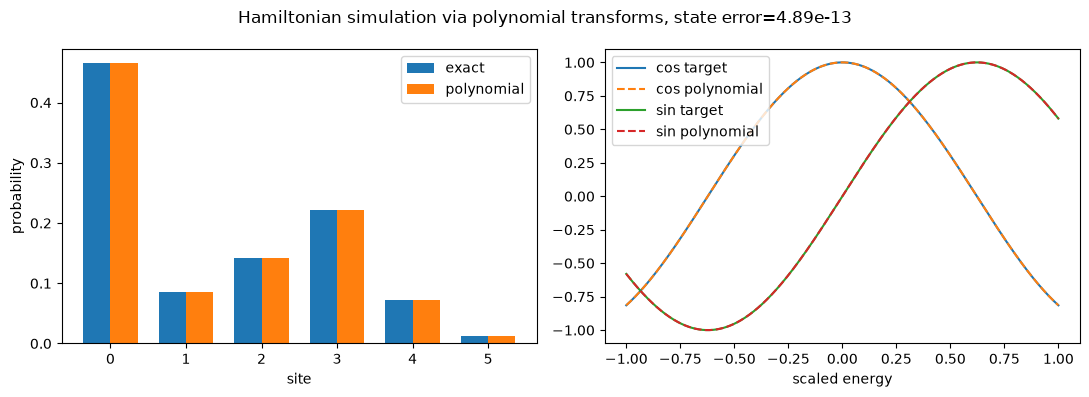

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(n_sites) - 0.18, np.abs(U_exact_psi) ** 2, 0.36, label="exact")
axes[0].bar(
    np.arange(n_sites) + 0.18, np.abs(U_poly_psi) ** 2, 0.36, label="polynomial"
)
axes[0].set_xlabel("site")
axes[0].set_ylabel("probability")
axes[0].legend()

xs = np.linspace(-1, 1, 500)
axes[1].plot(xs, np.cos(tau * xs), label="cos target")
axes[1].plot(
    xs, eval_polynomial(simulation.cos_coeffs, xs), "--", label="cos polynomial"
)
axes[1].plot(xs, np.sin(tau * xs), label="sin target")
axes[1].plot(
    xs, eval_polynomial(simulation.sin_coeffs, xs), "--", label="sin polynomial"
)
axes[1].set_xlabel("scaled energy")
axes[1].legend()
fig.suptitle(
    f"Hamiltonian simulation via polynomial transforms, state error={state_error:.2e}"
)
plt.tight_layout()
plt.show()